In [17]:
import json
import matplotlib
matplotlib.use("TkAgg")   # O prueba Qt5Agg, GTK3Agg, dependiendo de lo que tengas instalado
import numpy as np
import math
import pandas as pd
from collections import defaultdict
import gzip


In [11]:
def detectar_secuencias(archivo_entrada, archivo_salida):
    secuencias = []
    
    # Límites espaciales
    x_min, x_max = -480.0, 480.0
    y_min, y_max = -480.0, 480.0
    z_min, z_max = 0.0, 1330.0
    
    with open(archivo_entrada, "r") as f:
        lineas = [line.strip() for line in f if line.strip()]

    i = 0
    while i < len(lineas):
        secuencia_actual = []
        num_esperado = 1
        
        while i < len(lineas):
            partes = lineas[i].split()
            
            if len(partes) < 9:
                i += 1
                break

            try:
                col4_num = int(partes[3])   # número secuencial
                col5 = partes[4]           # tipo: compt o phot

                x = float(partes[5])       # columna 6
                y = float(partes[6])       # columna 7
                z = float(partes[7])       # columna 8

            except ValueError:
                break

            # Verificar consecutividad
            if col4_num == num_esperado:
                secuencia_actual.append(lineas[i])
                num_esperado += 1
                i += 1
            else:
                break

        # Validar secuencia mínima y tipo de interacciones
        if len(secuencia_actual) >= 2:
            tipos = [l.split()[4] for l in secuencia_actual]
            posiciones_validas = True

            for l in secuencia_actual:
                p = l.split()
                x, y, z = float(p[5]), float(p[6]), float(p[7])
                if not (x_min <= x <= x_max and y_min <= y <= y_max and z_min <= z <= z_max):
                    posiciones_validas = False
                    break

            if posiciones_validas and all(t == "compt" for t in tipos[:-1]) and tipos[-1] == "phot":
                secuencias.append(secuencia_actual)

        else:
            i += 1

    # Guardar resultados
    with open(archivo_salida, "w") as f:
        for sec in secuencias:
            for linea in sec:
                f.write(linea + "\n")
            f.write("\n")  # separación entre secuencias

    print(f"Se guardaron {len(secuencias)} secuencias en '{archivo_salida}'")


# Uso:
detectar_secuencias("Gamma-completo-neutrones-termicos-AP.txt", "secuencias_detectadas.txt")


FileNotFoundError: [Errno 2] No such file or directory: 'Gamma-completo-neutrones-termicos-AP.txt'

In [3]:
# Rango de coordenadas
x_min, x_max = -480.0, 480.0
y_min, y_max = -480.0, 480.0
z_min, z_max = 0.0, 1330.0

# Archivos
archivo_entrada = "gamma-completo.txt"
archivo_salida = "Gamma-completo-neutrones-termicos-AP.txt"

# Lista para guardar líneas filtradas
lineas_filtradas = []

with open(archivo_entrada, "r") as f:
    for linea in f:
        partes = linea.strip().split()
        
        # Asegurarse de que haya suficientes columnas
        if len(partes) < 9:
            continue
        
        try:
            x = float(partes[5])
            y = float(partes[6])
            z = float(partes[7])
        except ValueError:
            continue  # Saltar líneas con valores no numéricos
        
        # Comprobar condiciones
        if (x_min <= x <= x_max) and (y_min <= y <= y_max) and (z_min <= z <= z_max):
            lineas_filtradas.append(linea)

# Guardar en archivo
with open(archivo_salida, "w") as f_out:
    f_out.writelines(lineas_filtradas)

print(f"Se guardaron {len(lineas_filtradas)} líneas en {archivo_salida}")


Se guardaron 281426 líneas en Gamma-completo-neutrones-termicos-AP.txt


In [ ]:
# Abrir el archivo para lectura
with open('gamma-completo-5NaCl.txt', 'r') as archivo:
    # Inicializar una lista para almacenar los datos modificados
    data = []
    
    # Leer cada línea del archivo
    for linea in archivo:
        # Dividir la línea en columnas
        columnas = linea.split()
        
        # Obtener el valor de la columna 7 y convertirlo a flotante
        valor_columna_9 = float(columnas[8])
        
        # Multiplicar el valor de la columna 7 por 1000
        valor_columna_9_modificado = valor_columna_9*1 
        #if valor_columna_7_modificado > 2:
           # Agregar el valor modificado a la lista
        data.append(valor_columna_9_modificado)

num_bins = int(math.sqrt(len(data)))
# Graficar el histograma con marcadores triangulares
plt.figure(figsize=(12, 8))

# Crear histograma
#counts, bins, _ = plt.hist(data, bins=600, histtype='step', color='blue', label='Total', linewidth=1.7, log=True)
counts, bins, _ = plt.hist(data, bins=500000, histtype='step', color='purple', linewidth=1.7, log=True)
#counts, bins, _ = plt.hist(data, bins=num_bins, histtype='step', edgecolor='black', alpha=0.7)
# Puntos en el centro de cada bin
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Configurar el marcador a triángulo
#plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=4, color='blue', label='2x$10^{5}$ N. a 10 MeV en agua pura')
plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=4, color='purple')
#stats_text = f'Agua pura para n de 500 MeV'
#stats_text = f'Agua + 2.5 % de NaCl \nMean: \nRMS:'
#plt.text(0.60, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=14)
plt.tick_params(axis='y', which='both', direction='in', labelsize=12, right=True)
# Configuraciones adicionales
plt.title('')
plt.xlim(0, 10.01)
#plt.ylim(400, 60000)
plt.xticks(np.arange(0, 10.01, 0.5))
plt.tick_params(axis='x', which='both', labelsize=12)  # Tics mayores
# Aumentar el tamaño de las etiquetas de los ejes
plt.xticks(fontsize=12)
plt.yticks(fontsize=24)
plt.xlabel('Energía (MeV)', fontsize=24)
plt.ylabel('Counts [a.u.]', fontsize=24)
plt.yscale('log')
plt.grid(True)
#plt.legend()
pdf_filename_stat_charge = 'Espectro-gammas-Agua-5NaCl-principal.pdf'
plt.savefig(pdf_filename_stat_charge, format='pdf')
plt.savefig('Espectro-gammas-Agua-5NaCl-principal.jpg', format='jpg')
# Mostrar el gráfico
plt.show()

# Valor de energía que quieres consultar
x_objetivo = 2.2245
#x_objetivo1 = 0.51706962
x_objetivo1 = 0.49
x_objetivo2 = 1.164860
x_objetivo3 = 1.9511265
x_objetivo4 = 6.1109802
x_objetivo5 = 6.1109802

# Encontrar el índice del bin más cercano a 2.22
idx = (np.abs(bin_centers - x_objetivo)).argmin()
idx1 = (np.abs(bin_centers - x_objetivo1)).argmin()
idx2 = (np.abs(bin_centers - x_objetivo2)).argmin()
idx3 = (np.abs(bin_centers - x_objetivo3)).argmin()
idx4 = (np.abs(bin_centers - x_objetivo4)).argmin()

# Obtener el valor del histograma en ese bin
valor_y = counts[idx]
valor_x = bin_centers[idx]
valor_y1 = counts[idx1]
valor_x1 = bin_centers[idx1]
valor_y2 = counts[idx2]
valor_x2 = bin_centers[idx2]
valor_y3 = counts[idx3]
valor_x3 = bin_centers[idx3]
valor_y4 = counts[idx4]
valor_x4 = bin_centers[idx4]

print(f"Valor más cercano a {x_objetivo} MeV:")
print(f"Energía (x) = {valor_x:.5f} MeV")
print(f"Counts (y) = {valor_y}")

print(f"Valor más cercano a {x_objetivo1} MeV:")
print(f"Energía (x1) = {valor_x1:.5f} MeV")
print(f"Counts (y1) = {valor_y1}")

print(f"Valor más cercano a {x_objetivo2} MeV:")
print(f"Energía (x2) = {valor_x2:.5f} MeV")
print(f"Counts (y2) = {valor_y2}")

print(f"Valor más cercano a {x_objetivo3} MeV:")
print(f"Energía (x3) = {valor_x3:.5f} MeV")
print(f"Counts (y3) = {valor_y3}")

print(f"Valor más cercano a {x_objetivo4} MeV:")
print(f"Energía (x4) = {valor_x4:.5f} MeV")
print(f"Counts (y4) = {valor_y4}")



In [51]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Abrir el archivo para lectura
with open('gamma-completo-5NaCl.txt', 'r') as archivo:
    data = []
    for linea in archivo:
        columnas = linea.split()
        valor_columna_9 = float(columnas[8])
        valor_columna_9_modificado = valor_columna_9 * 1
        data.append(valor_columna_9_modificado)

num_bins = int(math.sqrt(len(data)))
plt.figure(figsize=(12, 8))

# Histograma
counts, bins, _ = plt.hist(
    data,
    bins=500000,
    histtype='step',
    color='purple',
    linewidth=1.7,
    log=True
)

# Puntos en el centro de cada bin
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=4, color='purple')

# Configuración de la gráfica
plt.tick_params(axis='y', which='both', direction='in', labelsize=24, right=True)
plt.title('')
plt.xlim(0, 10.01)
plt.xticks(np.arange(0, 10.01, 1))
plt.tick_params(axis='x', which='both', labelsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Energía [MeV]', fontsize=24)
plt.ylabel('Counts [a.u.]', fontsize=24)
plt.yscale('log')
plt.grid(True)

# Guardar
plt.savefig('Espectro-gammas-Agua-5NaCl.pdf', format='pdf')
plt.savefig('Espectro-gammas-Agua-5NaCl.jpg', format='jpg')

# Mostrar gráfico
plt.show()

# --- SECCIÓN INTERACTIVA ---
print("Haz clic en los puntos de interés (ej. picos). Cierra la ventana o presiona Enter para terminar.")
puntos = plt.ginput(n=-1, timeout=0)  # n=-1 = clicks ilimitados hasta cerrar
print("\nCoordenadas seleccionadas (x, y):")
for i, (E, I) in enumerate(puntos, 1):
    print(f"Energia {i}: E = {E:.4f}, I = {I:.4f}")


Haz clic en los puntos de interés (ej. picos). Cierra la ventana o presiona Enter para terminar.

Coordenadas seleccionadas (x, y):
Energia 1: E = 0.5083, I = 66393.4572
Energia 2: E = 0.7873, I = 19453.8877
Energia 3: E = 1.1660, I = 17258.1725
Energia 4: E = 1.6045, I = 5873.4114
Energia 5: E = 1.9534, I = 16749.1166
Energia 6: E = 2.2225, I = 50710.6513
Energia 7: E = 2.3121, I = 3426.4013
Energia 8: E = 2.6809, I = 2464.9399
Energia 9: E = 2.7407, I = 2950.0117
Energia 10: E = 2.8603, I = 6051.9220
Energia 11: E = 3.0496, I = 3530.5400
Energia 12: E = 3.3287, I = 1720.9630
Energia 13: E = 3.4284, I = 1720.9630
Energia 14: E = 3.4981, I = 1395.5688
Energia 15: E = 3.5679, I = 1998.8769
Energia 16: E = 3.8270, I = 2253.1891
Energia 17: E = 3.9765, I = 1773.2683
Energia 18: E = 4.0562, I = 1354.4044
Energia 19: E = 4.4349, I = 3426.4013
Energia 20: E = 4.7339, I = 1238.0542
Energia 21: E = 4.9432, I = 2186.7279
Energia 22: E = 4.9831, I = 3227.2487
Energia 23: E = 5.2422, I = 974.3533

In [45]:
# Abrir el archivo para lectura
with open('gamma-completo-10NaCl.txt', 'r') as archivo:
    # Inicializar una lista para almacenar los datos modificados
    data = []
    
    # Leer cada línea del archivo
    for linea in archivo:
        # Dividir la línea en columnas
        columnas = linea.split()
        
        # Obtener el valor de la columna 7 y convertirlo a flotante
        valor_columna_9 = float(columnas[8])
        
        # Multiplicar el valor de la columna 7 por 1000
        valor_columna_9_modificado = valor_columna_9*1 
        #if valor_columna_7_modificado > 2:
           # Agregar el valor modificado a la lista
        data.append(valor_columna_9_modificado)

num_bins = int(math.sqrt(len(data)))
# Graficar el histograma con marcadores triangulares
plt.figure(figsize=(12, 8))

# Crear histograma
#counts, bins, _ = plt.hist(data, bins=600, histtype='step', color='blue', label='Total', linewidth=1.7, log=True)
counts, bins, _ = plt.hist(data, bins=500000, histtype='step', color='orange', linewidth=1.7, log=True)
#counts, bins, _ = plt.hist(data, bins=num_bins, histtype='step', edgecolor='black', alpha=0.7)
# Puntos en el centro de cada bin
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Configurar el marcador a triángulo
#plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=4, color='blue', label='2x$10^{5}$ N. a 10 MeV en agua pura')
plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=4, color='orange')
#stats_text = f'Agua pura para n de 500 MeV'
#stats_text = f'Agua + 2.5 % de NaCl \nMean: \nRMS:'
#plt.text(0.60, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=14)
plt.tick_params(axis='y', which='both', direction='in', labelsize=20, right=True)
# Configuraciones adicionales
plt.title('')
plt.xlim(0, 10.01)
#plt.ylim(400, 60000)
plt.xticks(np.arange(0, 10.01, 1))
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
# Aumentar el tamaño de las etiquetas de los ejes
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Energy [MeV]', fontsize=24)
plt.ylabel('Counts [a.u.]', fontsize=24)
plt.yscale('log')
plt.grid(True)
#plt.legend()
pdf_filename_stat_charge = 'Espectro-gammas-Agua-10NaCl.pdf'
plt.savefig(pdf_filename_stat_charge, format='pdf')
plt.savefig('Espectro-gammas-Agua-10NaCl.jpg', format='jpg')
# Mostrar el gráfico
plt.show()

# Valor de energía que quieres consultar
x_objetivo = 2.2245

# Encontrar el índice del bin más cercano a 2.22
idx = (np.abs(bin_centers - x_objetivo)).argmin()

# Obtener el valor del histograma en ese bin
valor_y = counts[idx]
valor_x = bin_centers[idx]

print(f"Valor más cercano a {x_objetivo} MeV:")
print(f"Energía (x) = {valor_x:.5f} MeV")
print(f"Counts (y) = {valor_y}")

Valor más cercano a 2.2245 MeV:
Energía (x) = 2.22820 MeV
Counts (y) = 36862.0


In [49]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Abrir el archivo para lectura
with open('gamma-completo-10NaCl.txt', 'r') as archivo:
    data = []
    for linea in archivo:
        columnas = linea.split()
        valor_columna_9 = float(columnas[8])
        valor_columna_9_modificado = valor_columna_9 * 1
        data.append(valor_columna_9_modificado)

num_bins = int(math.sqrt(len(data)))
plt.figure(figsize=(12, 8))

# Histograma
counts, bins, _ = plt.hist(
    data,
    bins=500000,
    histtype='step',
    color='orange',
    linewidth=1.7,
    log=True
)

# Puntos en el centro de cada bin
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=4, color='orange')

# Configuración de la gráfica
plt.tick_params(axis='y', which='both', direction='in', labelsize=24, right=True)
plt.title('')
plt.xlim(0, 10.01)
plt.xticks(np.arange(0, 10.01, 1))
plt.tick_params(axis='x', which='both', labelsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Energía [MeV]', fontsize=24)
plt.ylabel('Counts [a.u.]', fontsize=24)
plt.yscale('log')
plt.grid(True)

# Guardar
plt.savefig('Espectro-gammas-Agua-10NaCl.pdf', format='pdf')
plt.savefig('Espectro-gammas-Agua-10NaCl.jpg', format='jpg')

# Mostrar gráfico
plt.show()

# --- SECCIÓN INTERACTIVA ---
print("Haz clic en los puntos de interés (ej. picos). Cierra la ventana o presiona Enter para terminar.")
puntos = plt.ginput(n=-1, timeout=0)  # n=-1 = clicks ilimitados hasta cerrar
print("\nCoordenadas seleccionadas (x, y):")
for i, (E, I) in enumerate(puntos, 1):
    print(f"Energia {i}: E = {E:.4f}, I = {I:.4f}")


Haz clic en los puntos de interés (ej. picos). Cierra la ventana o presiona Enter para terminar.


invalid command name "124954002129984delayed_destroy"
    while executing
"124954002129984delayed_destroy"
    ("after" script)
invalid command name "124953774784064delayed_destroy"
    while executing
"124953774784064delayed_destroy"
    ("after" script)
invalid command name "124953959355712delayed_destroy"
    while executing
"124953959355712delayed_destroy"
    ("after" script)



Coordenadas seleccionadas (x, y):
Energia 1: E = 0.5182, I = 96735.5827
Energia 2: E = 0.7873, I = 30962.6784
Energia 3: E = 1.1660, I = 24959.5988
Energia 4: E = 1.6145, I = 9910.3910
Energia 5: E = 1.9534, I = 18345.1808
Energia 6: E = 2.2225, I = 38409.5698
Energia 7: E = 2.3121, I = 5191.4422
Energia 8: E = 2.6809, I = 4450.7195
Energia 9: E = 2.7507, I = 4450.7195
Energia 10: E = 2.8503, I = 8238.7520
Energia 11: E = 3.0696, I = 5353.7685
Energia 12: E = 3.3287, I = 2804.5089
Energia 13: E = 3.4284, I = 3075.8950
Energia 14: E = 3.5978, I = 3699.9927
Energia 15: E = 3.8170, I = 3373.5425
Energia 16: E = 3.9865, I = 2637.0217
Energia 17: E = 4.0762, I = 2331.4573
Energia 18: E = 4.4349, I = 4315.7737
Energia 19: E = 4.7339, I = 1767.1907
Energia 20: E = 4.9731, I = 5191.4422
Energia 21: E = 4.9432, I = 2982.6338
Energia 22: E = 5.2422, I = 1713.6095
Energia 23: E = 5.5312, I = 2804.5089
Energia 24: E = 5.5810, I = 1611.2715
Energia 25: E = 5.7206, I = 6849.0773
Energia 26: E = 5.9

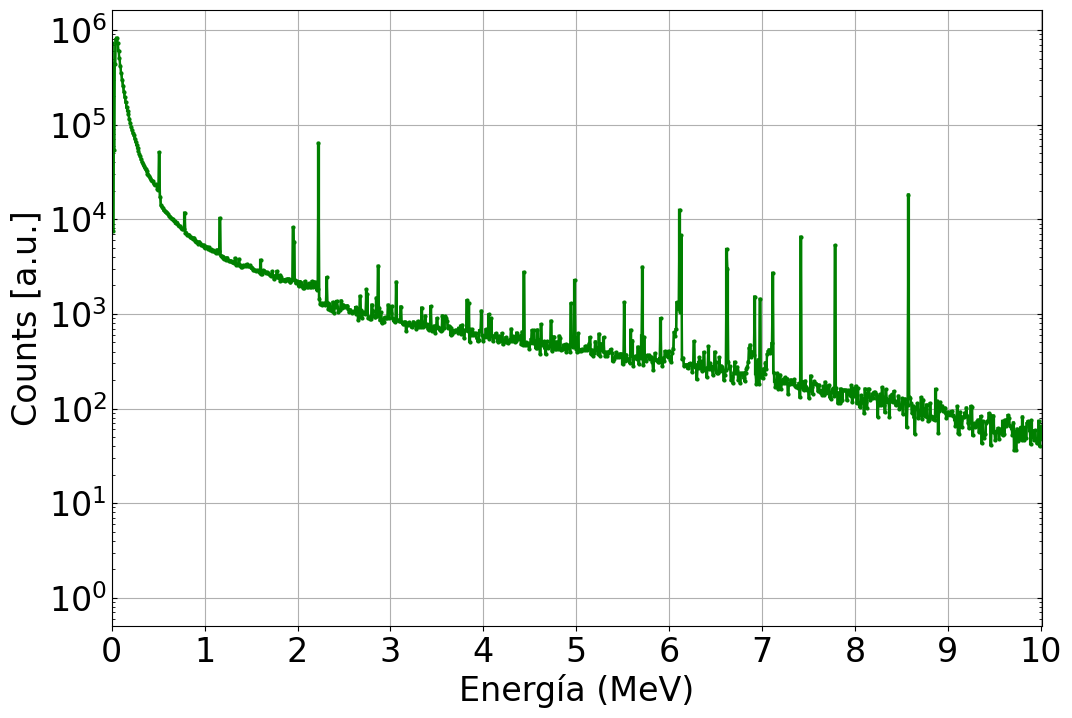

Valor más cercano a 2.2245 MeV:
Energía (x) = 2.22539 MeV
Counts (y) = 63986.0


In [21]:
# Abrir el archivo para lectura
with open('gamma-completo-25NaCl.txt', 'r') as archivo:
    # Inicializar una lista para almacenar los datos modificados
    data = []
    
    # Leer cada línea del archivo
    for linea in archivo:
        # Dividir la línea en columnas
        columnas = linea.split()
        
        # Obtener el valor de la columna 7 y convertirlo a flotante
        valor_columna_9 = float(columnas[8])
        
        # Multiplicar el valor de la columna 7 por 1000
        valor_columna_9_modificado = valor_columna_9*1 
        #if valor_columna_7_modificado > 2:
           # Agregar el valor modificado a la lista
        data.append(valor_columna_9_modificado)

num_bins = int(math.sqrt(len(data)))
# Graficar el histograma con marcadores triangulares
plt.figure(figsize=(12, 8))

# Crear histograma
#counts, bins, _ = plt.hist(data, bins=600, histtype='step', color='blue', label='Total', linewidth=1.7, log=True)
counts, bins, _ = plt.hist(data, bins=500000, histtype='step', color='green', linewidth=1.7, log=True)
#counts, bins, _ = plt.hist(data, bins=num_bins, histtype='step', edgecolor='black', alpha=0.7)
# Puntos en el centro de cada bin
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Configurar el marcador a triángulo
#plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=4, color='blue', label='2x$10^{5}$ N. a 10 MeV en agua pura')
plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=4, color='green')
#stats_text = f'Agua pura para n de 500 MeV'
#stats_text = f'Agua + 2.5 % de NaCl \nMean: \nRMS:'
#plt.text(0.60, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=14)
plt.tick_params(axis='y', which='both', direction='in', labelsize=20, right=True)
# Configuraciones adicionales
plt.title('')
plt.xlim(0, 10.01)
#plt.ylim(400, 60000)
plt.xticks(np.arange(0, 10.01, 1))
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
# Aumentar el tamaño de las etiquetas de los ejes
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Energía (MeV)', fontsize=24)
plt.ylabel('Counts [a.u.]', fontsize=24)
plt.yscale('log')
plt.grid(True)
#plt.legend()
pdf_filename_stat_charge = 'Espectro-gammas-Agua-25NaCl.pdf'
plt.savefig(pdf_filename_stat_charge, format='pdf')
plt.savefig('Espectro-gammas-Agua-25NaCl.jpg', format='jpg')
# Mostrar el gráfico
plt.show()

# Valor de energía que quieres consultar
x_objetivo = 2.2245

# Encontrar el índice del bin más cercano a 2.22
idx = (np.abs(bin_centers - x_objetivo)).argmin()

# Obtener el valor del histograma en ese bin
valor_y = counts[idx]
valor_x = bin_centers[idx]

print(f"Valor más cercano a {x_objetivo} MeV:")
print(f"Energía (x) = {valor_x:.5f} MeV")
print(f"Counts (y) = {valor_y}")

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Abrir el archivo para lectura
with open('gamma-completo-25NaCl.txt', 'r') as archivo:
    data = []
    for linea in archivo:
        columnas = linea.split()
        valor_columna_9 = float(columnas[8])
        valor_columna_9_modificado = valor_columna_9 * 1
        data.append(valor_columna_9_modificado)

num_bins = int(math.sqrt(len(data)))
plt.figure(figsize=(12, 8))

# Histograma
counts, bins, _ = plt.hist(
    data,
    bins=500000,
    histtype='step',
    color='purple',
    linewidth=1.7,
    log=True
)

# Puntos en el centro de cada bin
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=4, color='green')

# Configuración de la gráfica
plt.tick_params(axis='y', which='both', direction='in', labelsize=24, right=True)
plt.title('')
plt.xlim(0, 10.01)
plt.xticks(np.arange(0, 10.01, 1))
plt.tick_params(axis='x', which='both', labelsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Energía [MeV]', fontsize=24)
plt.ylabel('Counts [a.u.]', fontsize=24)
plt.yscale('log')
plt.grid(True)

# Guardar
plt.savefig('Espectro-gammas-Agua-25NaCl.pdf', format='pdf')
plt.savefig('Espectro-gammas-Agua-25NaCl.jpg', format='jpg')

# Mostrar gráfico
plt.show()

# --- SECCIÓN INTERACTIVA ---
print("Haz clic en los puntos de interés (ej. picos). Cierra la ventana o presiona Enter para terminar.")
puntos = plt.ginput(n=-1, timeout=0)  # n=-1 = clicks ilimitados hasta cerrar
print("\nCoordenadas seleccionadas (x, y):")
for i, (E, I) in enumerate(puntos, 1):
    print(f"Energia {i}: E = {E:.4f}, I = {I:.4f}")


Haz clic en los puntos de interés (ej. picos). Cierra la ventana o presiona Enter para terminar.

Coordenadas seleccionadas (x, y):
Energia 1: E = 0.5083, I = 50762.5767
Energia 2: E = 0.7873, I = 12582.3255
Energia 3: E = 1.1461, I = 10880.7429
Energia 4: E = 1.6045, I = 3712.7954
Energia 5: E = 1.9534, I = 8376.7255
Energia 6: E = 2.2225, I = 65936.8086
Energia 7: E = 2.3121, I = 2471.8060
Energia 8: E = 2.6709, I = 1552.6973
Energia 9: E = 2.7407, I = 1848.4582
Energia 10: E = 2.8603, I = 3402.8248
Energia 11: E = 3.0596, I = 2265.4421
Energia 12: E = 3.3287, I = 1266.9034
Energia 13: E = 3.4284, I = 1266.9034
Energia 14: E = 3.5679, I = 947.4117
Energia 15: E = 3.8270, I = 1423.0671
Energia 16: E = 3.9765, I = 1095.5725
Energia 17: E = 4.0662, I = 1004.1063
Energia 18: E = 4.4349, I = 2858.3589
Energia 19: E = 4.7140, I = 893.9182
Energia 20: E = 4.9432, I = 1342.7168
Energia 21: E = 4.9831, I = 2332.2410
Energia 22: E = 5.2422, I = 649.3406
Energia 23: E = 5.5113, I = 1423.0671
En

In [8]:
# Abrir el archivo para lectura

with open('gamma-completo-Agua-pura.txt', 'r') as archivo:
#with open('Gamma-captura-neutron-flujo-completo-AP.txt', 'r') as archivo:
    # Inicializar una lista para almacenar los datos modificados
    data = []
    
    # Leer cada línea del archivo
    for linea in archivo:
        # Dividir la línea en columnas
        columnas = linea.split()
        
        # Obtener el valor de la columna 7 y convertirlo a flotante
        valor_columna_9 = float(columnas[8])
        
        # Multiplicar el valor de la columna 7 por 1000
        valor_columna_9_modificado = valor_columna_9*1 
        #if valor_columna_7_modificado > 2:
           # Agregar el valor modificado a la lista
        data.append(valor_columna_9_modificado)

num_bins = int(math.sqrt(len(data)))
# Graficar el histograma con marcadores triangulares
plt.figure(figsize=(12, 8))

# Crear histograma
#counts, bins, _ = plt.hist(data, bins=600, histtype='step', color='blue', label='Total', linewidth=1.7, log=True)
counts, bins, _ = plt.hist(data, bins=500000, histtype='step', color='red', linewidth=1.7, log=True)
#counts, bins, _ = plt.hist(data, bins=num_bins, histtype='step', edgecolor='black', alpha=0.7)
# Puntos en el centro de cada bin
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Configurar el marcador a triángulo
#plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=4, color='blue', label='2x$10^{5}$ N. a 10 MeV en agua pura')
plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=4, color='red')
#stats_text = f'Agua pura para n de 500 MeV'
#stats_text = f'Agua + 2.5 % de NaCl \nMean: \nRMS:'
#plt.text(0.60, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=14)
plt.tick_params(axis='y', which='both', direction='in', labelsize=20, right=True)
# Configuraciones adicionales
plt.title('')
plt.xlim(0, 10.01)
#plt.ylim(400, 60000)
plt.xticks(np.arange(0, 10.01, 1))
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
# Aumentar el tamaño de las etiquetas de los ejes
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Energía (MeV)', fontsize=24)
plt.ylabel('Counts [a.u.]', fontsize=24)
plt.yscale('log')
plt.grid(True)
#plt.legend()
pdf_filename_stat_charge = 'Espectro-gammas-Agua-pura.pdf'
plt.savefig(pdf_filename_stat_charge, format='pdf')
plt.savefig('Espectro-gammas-Agua-pura.jpg', format='jpg')
# Mostrar el gráfico
plt.show()

# Valor de energía que quieres consultar
x_objetivo = 2.2245

# Encontrar el índice del bin más cercano a 2.22
idx = (np.abs(bin_centers - x_objetivo)).argmin()

# Obtener el valor del histograma en ese bin
valor_y = counts[idx]
valor_x = bin_centers[idx]

print(f"Valor más cercano a {x_objetivo} MeV:")
print(f"Energía (x) = {valor_x:.5f} MeV")
print(f"Counts (y) = {valor_y}")

KeyboardInterrupt: 

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Abrir el archivo para lectura
with open('gamma-completo-Agua-pura.txt', 'r') as archivo:
    data = []
    for linea in archivo:
        columnas = linea.split()
        valor_columna_9 = float(columnas[8])
        valor_columna_9_modificado = valor_columna_9 * 1
        data.append(valor_columna_9_modificado)

num_bins = int(math.sqrt(len(data)))
plt.figure(figsize=(12, 8))

# Histograma
counts, bins, _ = plt.hist(
    data,
    bins=500000,
    histtype='step',
    color='purple',
    linewidth=1.7,
    log=True
)

# Puntos en el centro de cada bin
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=4, color='red')

# Configuración de la gráfica
plt.tick_params(axis='y', which='both', direction='in', labelsize=24, right=True)
plt.title('')
plt.xlim(0, 10.01)
plt.xticks(np.arange(0, 10.01, 1))
plt.tick_params(axis='x', which='both', labelsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Energy [MeV]', fontsize=24)
plt.ylabel('Counts [a.u.]', fontsize=24)
plt.yscale('log')
plt.grid(True)

# Guardar
plt.savefig('Espectro-gammas-Agua-pura.pdf', format='pdf')
plt.savefig('Espectro-gammas-Agua-pura.jpg', format='jpg')

# Mostrar gráfico
plt.show()

# --- SECCIÓN INTERACTIVA ---
print("Haz clic en los puntos de interés (ej. picos). Cierra la ventana o presiona Enter para terminar.")
puntos = plt.ginput(n=-1, timeout=0)  # n=-1 = clicks ilimitados hasta cerrar
print("\nCoordenadas seleccionadas (x, y):")
for i, (E, I) in enumerate(puntos, 1):
    print(f"Energia {i}: E = {E:.4f}, I = {I:.4f}")


KeyboardInterrupt: 

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Abrir el archivo para lectura
with open('gamma-completo-Agua-pura.txt', 'r') as archivo:
    data = []
    for linea in archivo:
        columnas = linea.split()
        valor_columna_9 = float(columnas[8])
        valor_columna_9_modificado = valor_columna_9 * 1
        data.append(valor_columna_9_modificado)

num_bins = int(math.sqrt(len(data)))
plt.figure(figsize=(12, 8))

# Histograma
counts, bins, _ = plt.hist(
    data,
    bins=500000,
    histtype='step',
    color='purple',
    linewidth=1.7,
    log=True
)

# Puntos en el centro de cada bin
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=4, color='red')

# Configuración de la gráfica
plt.tick_params(axis='y', which='both', direction='in', labelsize=24, right=True)
plt.title('')
plt.xlim(0, 10.01)
plt.xticks(np.arange(0, 10.01, 1))
plt.tick_params(axis='x', which='both', labelsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Energía [MeV]', fontsize=24)
plt.ylabel('Counts [a.u.]', fontsize=24)
plt.yscale('log')
plt.grid(True)

# Guardar
plt.savefig('Espectro-gammas-Agua-pura.pdf', format='pdf')
plt.savefig('Espectro-gammas-Agua-pura.jpg', format='jpg')

# Mostrar gráfico
plt.show()

# --- SECCIÓN INTERACTIVA ---
print("Haz clic en los puntos de interés (ej. picos). Cierra la ventana o presiona Enter para terminar.")
puntos = plt.ginput(n=-1, timeout=0)  # n=-1 = clicks ilimitados hasta cerrar
print("\nCoordenadas seleccionadas (x, y):")
for i, (E, I) in enumerate(puntos, 1):
    print(f"Energia {i}: E = {E:.4f}, I = {I:.4f}")


Haz clic en los puntos de interés (ej. picos). Cierra la ventana o presiona Enter para terminar.

Coordenadas seleccionadas (x, y):
Energia 1: E = 0.5182, I = 44631.1839
Energia 2: E = 2.2324, I = 92576.5040
Energia 3: E = 2.7407, I = 1748.9182
Energia 4: E = 4.4449, I = 2208.8460
Energia 5: E = 6.1292, I = 7977.0666
Energia 6: E = 7.1158, I = 2872.3403


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor

# --- Lectura de archivo ---
with open('gamma-completo-Agua-pura.txt', 'r') as archivo:
    data = []
    for linea in archivo:
        columnas = linea.split()
        valor_columna_9 = float(columnas[8])
        data.append(valor_columna_9)

# Histograma
counts, bins, _ = plt.hist(data, bins=500000, histtype='step', color='red', linewidth=1.2, log=True)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.plot(bin_centers, counts, marker='.', linestyle='-', markersize=1, color='red')

plt.xlim(0, 10.01)
plt.yscale('log')
plt.xlabel('Energía (MeV)', fontsize=16)
plt.ylabel('Counts [a.u.]', fontsize=16)
plt.grid(True)

# --- Cursor que sigue al mouse ---
cursor = Cursor(plt.gca(), horizOn=True, vertOn=True, color='blue', linewidth=1.0)

# --- Evento al hacer clic ---
def onclick(event):
    if event.inaxes is not None:
        x_click = event.xdata
        idx = (np.abs(bin_centers - x_click)).argmin()
        x_val = bin_centers[idx]
        y_val = counts[idx]
        
        print(f"Seleccionaste: {x_val:.3f} MeV, Counts={y_val}")
        
        # Marca en la gráfica
        plt.plot(x_val, y_val, 'ro')
        plt.text(x_val, y_val, f"{x_val:.2f}, {int(y_val)}", fontsize=8, color="blue", rotation=45)
        plt.draw()

# Conectar el clic
plt.gcf().canvas.mpl_connect('button_press_event', onclick)

plt.show()
# Valor de energía que quieres consultar
x_objetivo = 2.2245

# Encontrar el índice del bin más cercano a 2.22
idx = (np.abs(bin_centers - x_objetivo)).argmin()

# Obtener el valor del histograma en ese bin
valor_y = counts[idx]
valor_x = bin_centers[idx]

print(f"Valor más cercano a {x_objetivo} MeV:")
print(f"Energía (x) = {valor_x:.5f} MeV")
print(f"Counts (y) = {valor_y}")



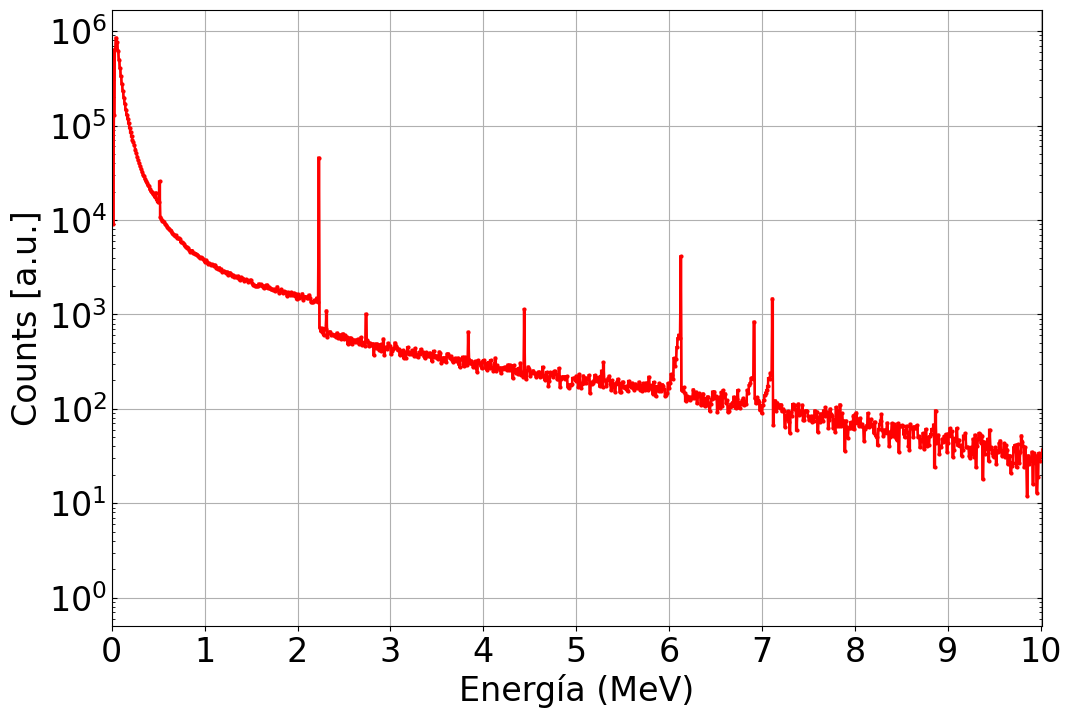

Valor más cercano a 2.2245 MeV:
Energía (x) = 2.22840 MeV
Counts (y) = 45638.0


In [33]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Límites espaciales
x_min, x_max = -480.0, 480.0
y_min, y_max = -480.0, 480.0
z_min, z_max = 0.0, 1330.0

# Abrir el archivo y leer datos filtrados
data = []
with open('gamma-completo-Agua-pura.txt', 'r') as archivo:
    for linea in archivo:
        columnas = linea.split()
        if len(columnas) < 9:  # seguridad por si hay líneas incompletas
            continue
        
        # Coordenadas (col 6=x, col 7=y, col 8=z) → indices 5,6,7
        x = float(columnas[5])
        y = float(columnas[6])
        z = float(columnas[7])
        
        # Valor de energía (col 9 → índice 8)
        energia = float(columnas[8])
        
        # Filtros espaciales
        if (x_min <= x <= x_max) and (y_min <= y <= y_max) and (z_min <= z <= z_max):
            data.append(energia)

# Calcular número de bins (o fijo como antes)
num_bins = int(math.sqrt(len(data)))

# Crear figura
plt.figure(figsize=(12, 8))

# Histograma con bins fijos grandes (como tu código original)
counts, bins, _ = plt.hist(data, bins=500000, histtype='step',
                           color='red', linewidth=1.7, log=True)

# Calcular centros de bins para la línea
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.plot(bin_centers, counts, marker='.', linestyle='-', 
         markersize=4, color='red')

# Estilo de ejes
plt.tick_params(axis='y', which='both', direction='in', labelsize=20, right=True)
plt.xlim(0, 10.01)
plt.xticks(np.arange(0, 10.01, 1), fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Energía (MeV)', fontsize=24)
plt.ylabel('Counts [a.u.]', fontsize=24)
plt.yscale('log')
plt.grid(True)

# Guardar
plt.savefig('Espectro-gammas-Agua-pura-filtrado.pdf', format='pdf')
plt.savefig('Espectro-gammas-Agua-pura-filtrado.jpg', format='jpg')

# Mostrar
plt.show()
# Valor de energía que quieres consultar
x_objetivo = 2.2245

# Encontrar el índice del bin más cercano a 2.22
idx = (np.abs(bin_centers - x_objetivo)).argmin()

# Obtener el valor del histograma en ese bin
valor_y = counts[idx]
valor_x = bin_centers[idx]

print(f"Valor más cercano a {x_objetivo} MeV:")
print(f"Energía (x) = {valor_x:.5f} MeV")
print(f"Counts (y) = {valor_y}")


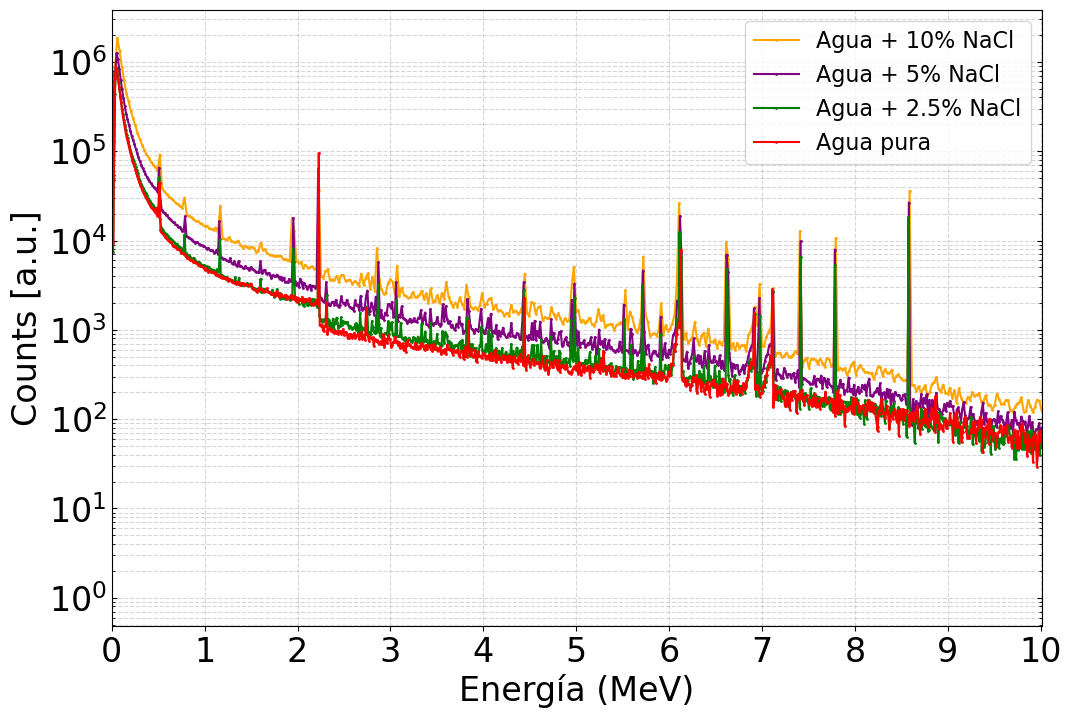

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Lista de archivos y sus etiquetas para la leyenda
archivos = [
    ("gamma-completo-10NaCl.txt", "Agua + 10% NaCl"),
    ("gamma-completo-5NaCl.txt",  "Agua + 5% NaCl"),
    ("gamma-completo-25NaCl.txt",  "Agua + 2.5% NaCl"),
    ("gamma-completo-Agua-pura.txt",   "Agua pura")
]

# Colores para diferenciar
colores = ["orange", "purple", "green", "red"]

# Tamaño de figura
plt.figure(figsize=(12, 8))

# Recorrer cada archivo
for (archivo, etiqueta), color in zip(archivos, colores):
    # Leer columna 9 (índice 8) y guardar datos
    with open(archivo, 'r') as f:
        data = [float(line.split()[8]) for line in f]
    
    # Histograma
    counts, bins = np.histogram(data, bins=500000)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    # Graficar con línea y marcadores
    plt.plot(bin_centers, counts, marker='.', linestyle='-', 
             markersize=2, color=color, linewidth=1.5, label=etiqueta)

# Configuración de ejes y estilo
plt.tick_params(axis='y', which='both', direction='in', labelsize=20, right=True)
plt.xlim(0, 10.01)
plt.xticks(np.arange(0, 10.01, 1))
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Energía (MeV)', fontsize=24)
plt.ylabel('Counts [a.u.]', fontsize=24)
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=16)

# Guardar en PDF y JPG
plt.savefig('Espectro-gammas.pdf', format='pdf')
plt.savefig('Espectro-gammas.jpg', format='jpg')

plt.show()


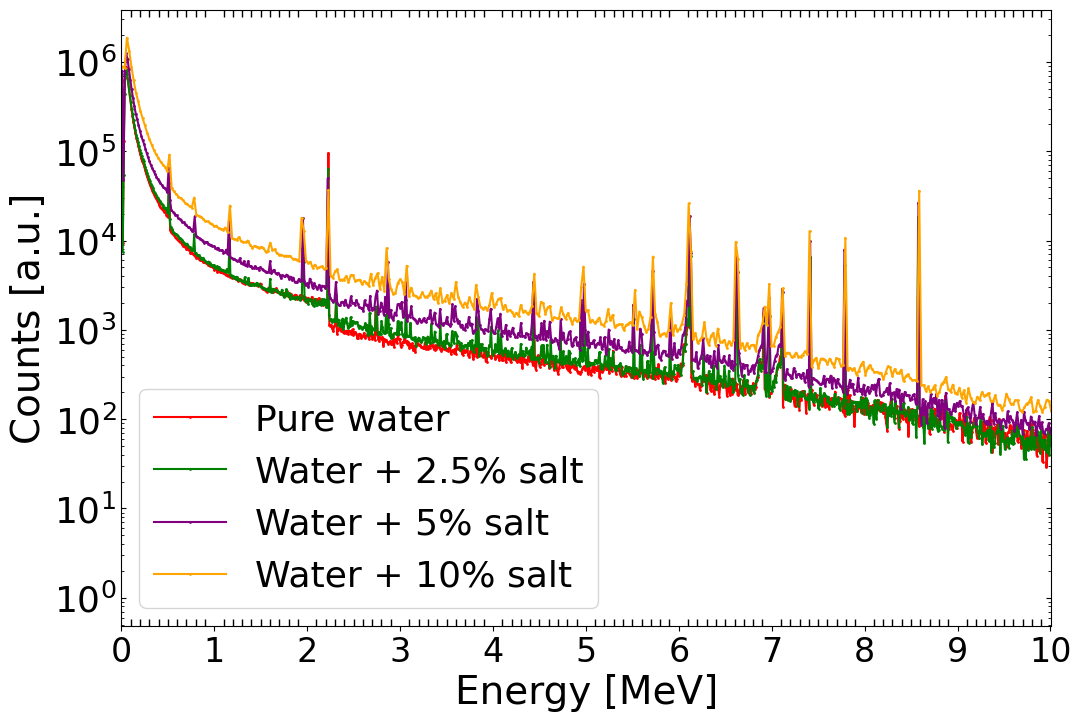

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.ticker import MultipleLocator

# Lista de archivos y sus etiquetas para la leyenda
archivos = [
    ("gamma-completo-Agua-pura.txt",   "Pure water"),
    ("gamma-completo-25NaCl.txt",  "Water + 2.5% salt"),
    ("gamma-completo-5NaCl.txt",  "Water + 5% salt"),
    ("gamma-completo-10NaCl.txt", "Water + 10% salt")
    
]

# Colores para diferenciar
colores = [ "red","green", "purple", "orange"]

# Tamaño de figura
plt.figure(figsize=(12, 8))

# Recorrer cada archivo
for (archivo, etiqueta), color in zip(archivos, colores):
    # Leer columna 9 (índice 8) y guardar datos
    with open(archivo, 'r') as f:
        data = [float(line.split()[8]) for line in f]
    
    # Histograma
    counts, bins = np.histogram(data, bins=500000)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    # Graficar con línea y marcadores
    plt.plot(bin_centers, counts, marker='.', linestyle='-', 
             markersize=2, color=color, linewidth=1.5, label=etiqueta)

# Configuración de ejes y estilo
plt.tick_params(axis='y', which='both', direction='in', labelsize=24, right=True)
plt.xlim(0, 10.01)
plt.xticks(np.arange(0, 10.01, 1), fontsize=24)  # Ticks mayores con etiquetas grandes

# Minor ticks cada 0.1 en X, sin etiquetas
plt.gca().xaxis.set_minor_locator(MultipleLocator(0.1))
plt.tick_params(axis='x', which='minor', length=5, width=1, direction='in', bottom=True, top=True, labelbottom=False)

plt.yticks(fontsize=26)
plt.xlabel('Energy [MeV]', fontsize=28)
plt.ylabel('Counts [a.u.]', fontsize=28)
plt.yscale('log')
#plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=26)

# Guardar en PDF y JPG
plt.savefig('Espectro-gamma.pdf', format='pdf')
plt.savefig('Espectro-gamma.jpg', format='jpg')

plt.show()
